In [1]:
import numpy as np
import scipy as sp
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal,norm
from collections import defaultdict
import warnings
import argparse
import sklearn.exceptions
from scipy.special import erfinv
import time
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

from _util import *

warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)

import rpy2.robjects as robjects
from rpy2.robjects import numpy2ri

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

np.set_printoptions(edgeitems=30, linewidth=100000, formatter=dict(float=lambda x: "%.3g" % x))
make_plot = lambda n,m,s=[1,1],sharex=False, sharey=False: plt.subplots(n,m,figsize=(m*3*s[0],n*2.5*s[1]),squeeze=False,layout='tight',sharex=sharex, sharey=sharey)

def rank_approx(A, k,sort_type="big_small"):
    # Eigenvalue Decomposition (since A is symmetric, we can use eigh)
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Sort eigenvalues and corresponding eigenvectors in descending order
    if sort_type == "big_small":
        idx = np.argsort(eigenvalues)[::-1]
    elif sort_type == "small_big":
        idx = np.argsort(eigenvalues)
    
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select the top-k eigenvalues and eigenvectors
    top_eigenvalues = np.diag(eigenvalues[:k])
    top_eigenvectors = eigenvectors[:, :k]
    
    # Reconstruct the rank-k approximation
    A_k = top_eigenvectors @ top_eigenvalues @ top_eigenvectors.T
    
    return A_k


def print_eig(matrix):

    # Validate symmetry
    if not np.allclose(matrix, matrix.T):
      raise ValueError("Error: The matrix is not symmetric.")
    
    # Compute eigenvalues and eigenvectors using an algorithm optimized for symmetric matrices
    eigenvalues, eigenvectors = np.linalg.eigh(matrix)
    
    # Sort eigenvalues and corresponding eigenvectors in ascending order.
    sorted_indices = np.argsort(eigenvalues)
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]
    
    # Create a DataFrame where each column header is a sorted eigenvalue,
    # and the column entries are the corresponding eigenvector components.
    df = pd.DataFrame(sorted_eigenvectors, columns=[f"{val:.4f}" for val in sorted_eigenvalues])
    
    # Append the final row labeled "sum" with the sum of each column (eigenvector)
    df.loc['sum'] = df.sum(axis=0)
    
    # Configure Pandas display options to avoid wrapping the DataFrame after a set number of columns.
    pd.set_option('display.max_columns', None)
    pd.set_option('display.expand_frame_repr', False)
    
    # Print the table to the console.
    print("Eigenvalue Table:")
    print(df)

def compute_metrics(result, C_true, iC_true, Y):

    if result is None or np.isnan(np.sum(result.iC)):
        result_metrics = {
            'err_C': np.nan,
            'err_iC': np.nan,
            'err_S': np.nan,
            'nnz': np.nan,
            'nll': np.nan,
            'sphr': np.nan,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'kl': np.nan,
            'runtime': np.nan
        }
        return SimpleNamespace(**result_metrics)

    p, n = Y.shape
    S   = np.cov(Y, bias=True)
    C   = result.C
    iC  = result.iC

    # Use X if available, otherwise default to iC
    X = result.X if hasattr(result, "X") else iC

    # Compute error metrics on covariance/precision matrices
    err_C  = np.linalg.norm(C  - C_true, ord="fro")**2 / np.linalg.norm(C_true, ord="fro")**2
    err_iC = np.linalg.norm(iC - iC_true, ord="fro")**2 / np.linalg.norm(iC_true, ord="fro")**2
    err_S  = np.linalg.norm(C  - S, ord="fro")**2
    nnz    = np.count_nonzero(X) / p
    nll    = -np.log(np.linalg.det(iC)) + np.trace(iC @ S)
    sphr   = p * np.trace(X @ X) / np.trace(X)**2 - 1 
    
    # Compute KL divergence loss for two zero-mean Gaussians.
    # KL = 0.5 * (trace(iC @ C_true) - p + log(det(C) / det(C_true)))
    kl = 0.5 * (np.trace(iC @ C_true) - p + np.log(np.linalg.det(C) / np.linalg.det(C_true)))
    
    # Compute F1 score for structure recovery of the precision matrix.
    # Threshold the absolute values to define nonzero connections.
    tol = 1e-5
    est_support = np.abs(iC) > tol
    true_support = np.abs(iC_true) > tol

    # Exclude the diagonal entries from evaluation.
    np.fill_diagonal(est_support, False)
    np.fill_diagonal(true_support, False)

    # Compute true positives, false positives, and false negatives.
    TP = np.sum(est_support & true_support)
    FP = np.sum(est_support & ~true_support)
    FN = np.sum(~est_support & true_support)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Compile all computed metrics into a structured object.
    result_metrics = {
        'err_C': err_C,
        'err_iC': err_iC,
        'err_S': err_S,
        'nnz': nnz,
        'nll': nll,
        'sphr': sphr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'kl': kl,
        'runtime': result.runtime
    }
    return SimpleNamespace(**result_metrics)

def metrics_list(results):
    if len(results)<1:
        return []
    if isinstance(results, list) and results:
        # Dynamically retrieve keys from the first result (e.g., 'err_C', 'err_iC', etc.)
        keys = vars(results[0]).keys()
        aggregated = {key: [getattr(r, key) for r in results] for key in keys}
        return SimpleNamespace(**aggregated)
    else:
        return results


During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 


# Tunning Paramter

In [ ]:
def cov_analysis(p=32, num=5000, gamma=0.01, k=50, data_method='cluster', seed=3):

    # Generate true covariance
    iC_true, C_true = make_cov(p, data_type=data_method, seed=seed)

    C = np.eye(p)

    # Initialize lists to store sample covariance and deviations from C
    S_k = []
    G_k = []

    # Generate samples and compute covariances
    for i in range(num):
        Y_k      = make_samples(cov=C_true, n=k,seed=i)
        Y_k, _,_ = normalize_data(Y_k)
        S_k.append(np.cov(Y_k, bias=True))
        G_k.append(S_k[-1] - C)

    # Convert lists to arrays
    S_k = np.array(S_k)
    G_k = np.array(G_k)

    # Calculate mean and variance of S_k
    S = np.mean(S_k, axis=0)
    G = np.mean(G_k, axis=0)
    V = np.outer(np.diag(S), np.diag(S)) + S ** 2

    # Compute confidence threshold L
    L = erfinv(1 - 2 * gamma) / np.sqrt(2 * k) * np.sqrt(V)

    # Compute mean of indicator matrices
    P_mean = np.zeros((p, p))
    for G_ki in G_k:
        P_mean = P_mean + (np.abs(G_ki) > L).astype(int)
    P_mean = P_mean/num

    # Compute final selection matrix and filter values
    P_select = (np.abs(G) > L).astype(int)
    T = (P_mean * P_select).flatten()
    T = T[T != 0]
    return T

fig, axs = make_plot(1,2,s=[1.1,1],sharex=False, sharey=True)

k           = 128
data_method = 'cluster'
gamma= 0.01
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 0].plot(np.sort(T),         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
axs[0, 0].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
axs[0, 0].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

gamma= 0.1
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 0].plot(np.sort(T),         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
axs[0, 0].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
axs[0, 0].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

gamma= 0.4
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 0].plot(np.sort(T),         color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
axs[0, 0].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
axs[0, 0].axvline(x=len(T),        color='red', linestyle='-.',alpha=.5)

data_method = 'band'
gamma= 0.01
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 1].plot(np.sort(T),         color='black',linewidth=2, linestyle='-',label=rf'$\gamma={gamma}\;$')
axs[0, 1].axhline(y=(0.5 + gamma), color='black', linestyle='-',alpha=.5)
axs[0, 1].axvline(x=len(T),        color='black', linestyle='-',alpha=.5)

gamma= 0.1
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 1].plot(np.sort(T),         color='blue',linewidth=2, linestyle='--',label=rf'$\gamma={gamma}\;$')
axs[0, 1].axhline(y=(0.5 + gamma), color='blue', linestyle='--',alpha=.5)
axs[0, 1].axvline(x=len(T),        color='blue', linestyle='--',alpha=.5)

gamma= 0.4
T = cov_analysis(gamma=gamma, k=k, data_method=data_method)
axs[0, 1].plot(np.sort(T),         color='red',linewidth=2, linestyle='-.',label=rf'$\gamma={gamma}\;$')
axs[0, 1].axhline(y=(0.5 + gamma), color='red', linestyle='-.',alpha=.5)
axs[0, 1].axvline(x=len(T),        color='red', linestyle='-.',alpha=.5)


axs[0, 0].legend(loc='center',frameon=False)
axs[0, 0].set_ylabel(r'Measured Prob. of Reselection')
axs[0, 0].set_xlabel(r'Index Count ($\;(i,j) \in \mathcal{I}_{\tiny{\text{u}}}\;$)')
axs[0, 1].set_xlabel(r'Index Count ($\;(i,j) \in \mathcal{I}_{\tiny{\text{u}}}\;$)')
#axs[0, 2].set_xlabel(r'Nonzero Indices ($(i,j) \in \mathcal{I}_{\tiny{\text{free}}}$)')

fig.savefig("fig_lambda_reselection_probability.png", dpi=300, bbox_inches='tight')

# Err 1

In [ ]:
def single_run(inx, n_ratio, kc, C_true, iC_true):
    
    p = C_true.shape[0]
    n = int( np.ceil(n_ratio * p))
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    met_glasso = None
    met_tiger  = None
    met_clime  = None
    met_aquic  = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    res_clime  = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC 
    res_aquic = compute_aquic(Y, k=n / kc)
    met_aquic = compute_metrics(res_aquic, C_true, iC_true, Y)

    print(f"- glasso {met_glasso.runtime:.3f} | tiger {met_tiger.runtime:.3f} | clime {met_clime.runtime:.3f} | aquic {met_aquic.runtime:.3f}")

    return {
        'glasso': met_glasso,
        'tiger':  met_tiger,
        'clime':  met_clime,
        'aquic':  met_aquic,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out


p  = 128
kc = 2
N  = 10

import os
os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses


#data_type_list = ["cluster", "band", "random", "hub", "sf"]
data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("Processing data type:", data_type)
    
    # Generate covariance matrix and samples.
    iC_true, C_true = make_cov(p, data_type=data_type, seed=np.random.randint(1))

    # Define the n_ratio values.
    n_ratio_set = [.1, .2, .3, .4, .5, .6, 0.7, 0.8, 0.9, 1.0]

    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for n_ratio in n_ratio_set:
        print(f"Running n_ratio={n_ratio} iterations")
        
        task_input_list = [(inx, n_ratio, kc, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"n_ratio={n_ratio} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

pd.to_pickle([n_ratio_set,dataframes], 'data_err1_p'+str(p)+ '_kc' + str(kc) + '_N' + str(N) + '.pkl')    

In [ ]:
file_name = "err1_p128_kc2_N10"
[x_line, dataframe] = pd.read_pickle("data_"+file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # KL divergence
    m = dataframe[data_type]['aquic'].kl.mean(0)
    v = dataframe[data_type]['aquic'].kl.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle="-", label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=":", label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([1e0, 1e2])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # error in C and iC
    m = (dataframe[data_type]['aquic'].err_iC.mean(0) + dataframe[data_type]['aquic'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['aquic'].err_iC.std(0) + dataframe[data_type]['aquic'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle="-", label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="black", label=r"$\texttt{aquic}$")

    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="blue", label=r"$\texttt{glasso}$")

    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2
    v = v * std_band  
    axs[i, inx].semilogy(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="red", label=r"$\texttt{tiger}$")

    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([1e-2, 1e0])
axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # Recall
    m = dataframe[data_type]['aquic'].recall.mean(0)
    v = dataframe[data_type]['aquic'].recall.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="blue",linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # Precision
    m = dataframe[data_type]['aquic'].precision.mean(0)
    v = dataframe[data_type]['aquic'].precision.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # F1 score
    m = dataframe[data_type]['aquic'].f1.mean(0)
    v = dataframe[data_type]['aquic'].f1.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0)
    v = v * std_band
    axs[i, inx].plot(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # nnz
    m = dataframe[data_type]['aquic'].nnz.mean(0)
    v = dataframe[data_type]['aquic'].nnz.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # KL divergence
    m = dataframe[data_type]['aquic'].runtime.mean(0)
    v = dataframe[data_type]['aquic'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0)
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].semilogy(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")
    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Number of Samples per Feature ($n/p$)')
    
# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime')

axs[i, 0].minorticks_on()

fig.savefig("fig_"+file_name+".png", dpi=300, bbox_inches='tight')

fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])

# Err 2

In [ ]:
def single_run(inx, n, kc, C_true, iC_true):
    
    p = C_true.shape[0]
    Y = make_samples(cov=C_true, n=int(n), seed=inx)
    
    met_glasso = None
    met_tiger  = None
    met_clime  = None
    met_aquic  = None

    # GLASSO
    res_glasso = compute_glasso(Y)
    met_glasso = compute_metrics(res_glasso, C_true, iC_true, Y)

    #TIGER 
    res_tiger = compute_tiger(Y)
    met_tiger = compute_metrics(res_tiger, C_true, iC_true, Y)

    # CLIME  
    res_clime  = compute_clime(Y)
    met_clime = compute_metrics(res_clime, C_true, iC_true, Y)

    # AQUIC
    k = n/2
    res_aquic = compute_aquic(Y, k=k)
    met_aquic = compute_metrics(res_aquic, C_true, iC_true, Y)

    print(f"- glasso {met_glasso.runtime:.3f} | tiger {met_tiger.runtime:.3f} | clime {met_clime.runtime:.3f} | aquic {met_aquic.runtime:.3f}")

    return {
        'glasso': met_glasso,
        'tiger':  met_tiger,
        'clime':  met_clime,
        'aquic':  met_aquic,
    }

def convert_to_dataframes(raw_data):
    out = {}
    # Use the methods in the first task result as reference.
    for method in raw_data[0]:
        # Get the metric names from the first non-None result.
        first_valid = next((ns for ns in raw_data[0][method] if ns is not None), None)
        if first_valid is None:
            continue
        metric_names = list(first_valid.__dict__.keys())
        method_metrics = {}
        # For each metric, build one column per task.
        for metric in metric_names:
            # Each column corresponds to one task (one n_ratio value)
            cols = [
                np.array([ns.__dict__[metric] if ns is not None else np.nan for ns in task[method]])
                for task in raw_data
            ]
            # Stack columns horizontally so that rows are iterations.
            matrix = np.column_stack(cols)
            method_metrics[metric] = pd.DataFrame(matrix, columns=list(range(len(raw_data))))
        out[method] = SimpleNamespace(**method_metrics)
    return out


pn = 4
kc = 2
N  = 10

import os
os.environ["PYTHONWARNINGS"] = "ignore"  # Applies to all subprocesses

#data_type_list = ["cluster", "band", "random", "hub", "sf"]
data_type_list = ["cluster", "band", "hub"]

dataframes = {}
for data_type in data_type_list:
    print("Processing data type:", data_type)
    
    # Define the n_ratio values.
    p_set = [32,64,128,256,512]

    # For each n_ratio value, run 100 iterations in parallel.
    raw_data = []  # Will be a list (length = number of n_ratio values).
    for p in p_set:
        print(f"Running p={p} iterations")
        # Generate covariance matrix and samples.
        iC_true, C_true = make_cov(p, data_type=data_type, seed=np.random.randint(1))
        n = p / pn
        task_input_list = [(inx, n, kc, C_true, iC_true) for inx in range(N)]
        single_results = []
        for args in tqdm(task_input_list, total=N, desc=f"p={p} iterations"):
            result = single_run(*args)
            single_results.append(result)
        
        # For each method, we now want a list of 100 results.
        task_result = {method: [res[method] for res in single_results]
                       for method in single_results[0]}
        raw_data.append(task_result)
    
    # Convert the raw_data (list per n_ratio value) into matrices per metric.
    dataframes[data_type] = convert_to_dataframes(raw_data)

pd.to_pickle([p_set,dataframes], 'data_err2_pn'+str(pn)+ '_kc' + str(kc) + '_N' + str(N) + '.pkl')    

Processing data type: cluster
Running p=32 iterations


p=32 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

R[write to console]: Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'diag': supply both 'x' and 'y' or a matrix-like 'x'

R[write to console]: Timing stopped at: 0.961 0.154 0.143

R[write to console]: Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'diag': supply both 'x' and 'y' or a matrix-like 'x'

R[write to console]: Timing stopped at: 0.157 0.003 0.161



- glasso 0.315 | tiger nan | clime nan | aquic 0.000


R[write to console]: Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'diag': supply both 'x' and 'y' or a matrix-like 'x'

R[write to console]: Timing stopped at: 0.713 0.105 0.122

R[write to console]: Error in h(simpleError(msg, call)) : 
  error in evaluating the argument 'x' in selecting a method for function 'diag': supply both 'x' and 'y' or a matrix-like 'x'

R[write to console]: Timing stopped at: 0.315 0.004 0.146



- glasso 0.225 | tiger nan | clime nan | aquic 0.000
Running p=64 iterations


p=64 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

- glasso 1.101 | tiger 0.507 | clime 1.154 | aquic 0.001
- glasso 0.341 | tiger 0.559 | clime 0.898 | aquic 0.001
Running p=128 iterations


p=128 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

Figure size (width x height in pixels): [9 12.2] 1.3611111111111112


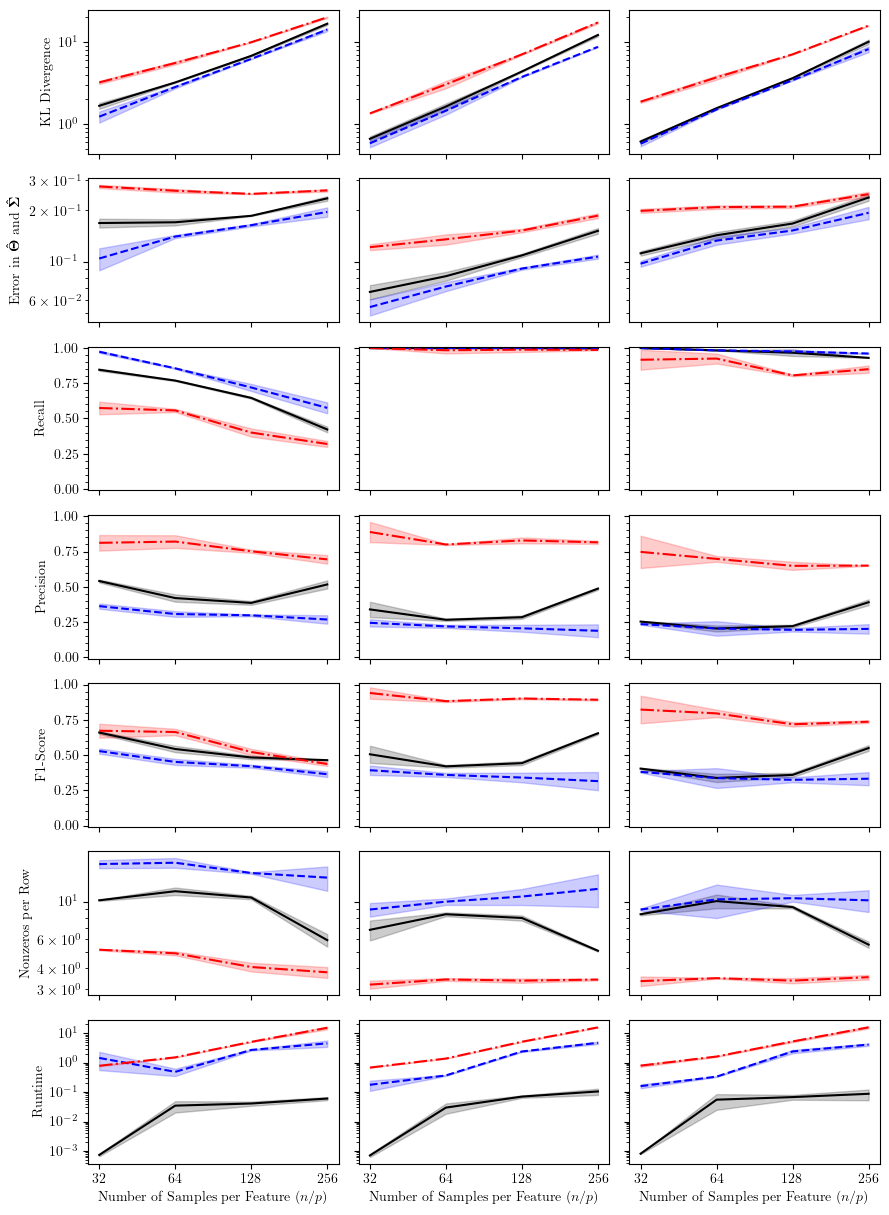

In [45]:
file_name = "err2_n128_kc2_N2"
[x_line, dataframe] = pd.read_pickle("data_"+file_name + ".pkl") 

fig, axs = make_plot(7, 3, s=[1, .7], sharex=True, sharey='row')

std_band = 1

i = 0
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # KL divergence
    m = dataframe[data_type]['aquic'].kl.mean(0)
    v = dataframe[data_type]['aquic'].kl.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle="-", label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].kl.mean(0)
    v = dataframe[data_type]['glasso'].kl.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].kl.mean(0)
    v = dataframe[data_type]['tiger'].kl.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].kl.mean(0)
    v = dataframe[data_type]['clime'].kl.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=":", label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([1e0, 1e2])
axs[i, 0].set_ylabel(r'KL Divergence')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # error in C and iC
    m = (dataframe[data_type]['aquic'].err_iC.mean(0) + dataframe[data_type]['aquic'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['aquic'].err_iC.std(0) + dataframe[data_type]['aquic'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle="-", label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="black", label=r"$\texttt{aquic}$")

    m = (dataframe[data_type]['glasso'].err_iC.mean(0) + dataframe[data_type]['glasso'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['glasso'].err_iC.std(0) + dataframe[data_type]['glasso'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="blue", label=r"$\texttt{glasso}$")

    m = (dataframe[data_type]['tiger'].err_iC.mean(0) + dataframe[data_type]['tiger'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['tiger'].err_iC.std(0) + dataframe[data_type]['tiger'].err_C.std(0)) / 2
    v = v * std_band  
    axs[i, inx].loglog(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="red", label=r"$\texttt{tiger}$")

    m = (dataframe[data_type]['clime'].err_iC.mean(0) + dataframe[data_type]['clime'].err_C.mean(0)) / 2
    v = (dataframe[data_type]['clime'].err_iC.std(0) + dataframe[data_type]['clime'].err_C.std(0)) / 2
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=0.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([1e-2, 1e0])
axs[i, 0].set_ylabel(r"Error in $\mathbf{\hat{\Theta}}$ and $\mathbf{\hat{\Sigma}}$")
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # Recall
    m = dataframe[data_type]['aquic'].recall.mean(0)
    v = dataframe[data_type]['aquic'].recall.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].recall.mean(0)
    v = dataframe[data_type]['glasso'].recall.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="blue",linestyle="--", label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].recall.mean(0)
    v = dataframe[data_type]['tiger'].recall.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].recall.mean(0)
    v = dataframe[data_type]['clime'].recall.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Recall')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # Precision
    m = dataframe[data_type]['aquic'].precision.mean(0)
    v = dataframe[data_type]['aquic'].precision.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].precision.mean(0)
    v = dataframe[data_type]['glasso'].precision.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].precision.mean(0)
    v = dataframe[data_type]['tiger'].precision.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].precision.mean(0)
    v = dataframe[data_type]['clime'].precision.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'Precision')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # F1 score
    m = dataframe[data_type]['aquic'].f1.mean(0)
    v = dataframe[data_type]['aquic'].f1.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].f1.mean(0)
    v = dataframe[data_type]['glasso'].f1.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].f1.mean(0)
    v = dataframe[data_type]['tiger'].f1.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].f1.mean(0)
    v = dataframe[data_type]['clime'].f1.std(0)
    v = v * std_band
    axs[i, inx].semilogx(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

axs[i, 0].set_ylim([-0.01, 1.01])
axs[i, 0].set_ylabel(r'F1-Score')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # nnz
    m = dataframe[data_type]['aquic'].nnz.mean(0)
    v = dataframe[data_type]['aquic'].nnz.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].nnz.mean(0)
    v = dataframe[data_type]['glasso'].nnz.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].nnz.mean(0)
    v = dataframe[data_type]['tiger'].nnz.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].nnz.mean(0)
    v = dataframe[data_type]['clime'].nnz.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")

# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Nonzeros per Row')
axs[i, 0].minorticks_on()

i = i + 1
for inx, data_type in enumerate(["cluster", "band", "hub"]):
    # KL divergence
    m = dataframe[data_type]['aquic'].runtime.mean(0)
    v = dataframe[data_type]['aquic'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="black", linestyle="-",label=r"$\texttt{aquic}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="black", label=r"$\texttt{aquic}$")

    m = dataframe[data_type]['glasso'].runtime.mean(0)
    v = dataframe[data_type]['glasso'].runtime.std(0)
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="blue", linestyle="--",label=r"$\texttt{glasso}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="blue", label=r"$\texttt{glasso}$")

    m = dataframe[data_type]['tiger'].runtime.mean(0)
    v = dataframe[data_type]['tiger'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="red", linestyle="-.",label=r"$\texttt{tiger}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="red", label=r"$\texttt{tiger}$")

    m = dataframe[data_type]['clime'].runtime.mean(0)
    v = dataframe[data_type]['clime'].runtime.std(0) 
    v = v * std_band
    axs[i, inx].loglog(x_line, m, color="green", linestyle=":",label=r"$\texttt{clime}$")
    axs[i, inx].fill_between(x_line, m + v, m - v, alpha=.2, color="green", label=r"$\texttt{clime}$")
    
    axs[i, inx].set_xticks(x_line)
    axs[i, inx].set_xlabel(r'Number of Samples per Feature ($n/p$)')
    
# axs[i, 0].set_ylim([0, 1])
axs[i, 0].set_ylabel(r'Runtime')
axs[i, 0].minorticks_on()
axs[i, 0].set_xscale('log', base=2)

axs[i, 0].set_xticks(x_line)
axs[i, 0].set_xticklabels([str(int(val)) for val in x_line])

fig.savefig("fig_"+file_name+".png", dpi=300, bbox_inches='tight')

fig_size_pixels = fig.get_size_inches() 
print("Figure size (width x height in pixels):", fig_size_pixels,fig_size_pixels[1]/fig_size_pixels[0])

In [9]:
p=128
data_type = "cluster"
iC_true, C_true = make_cov(p, data_type=data_type, seed=np.random.randint(1))

nonzero_count = np.count_nonzero(iC_true)/p
print(f"Number of nonzero elements in iC_true: {nonzero_count}")


Number of nonzero elements in iC_true: 6.71875
